# Task 2: What Affects Tool (Skill) Unlocks

This analysis focuses specifically on the `tool` mode runs, where the LLM can buy and unlock skills from the skill tree using accrued Skill Points.

## 2.1 Aggregate Overview (Tasks 2a, 2c)
Here we show the most frequently unlocked skills across all `tool` runs and an aggregate list of the stated reasons the LLM provided for unlocking them.

/tmp/ipykernel_9393/3564141126.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=skill_counts, x='Skill', y='Unlock Count', palette='Set2')


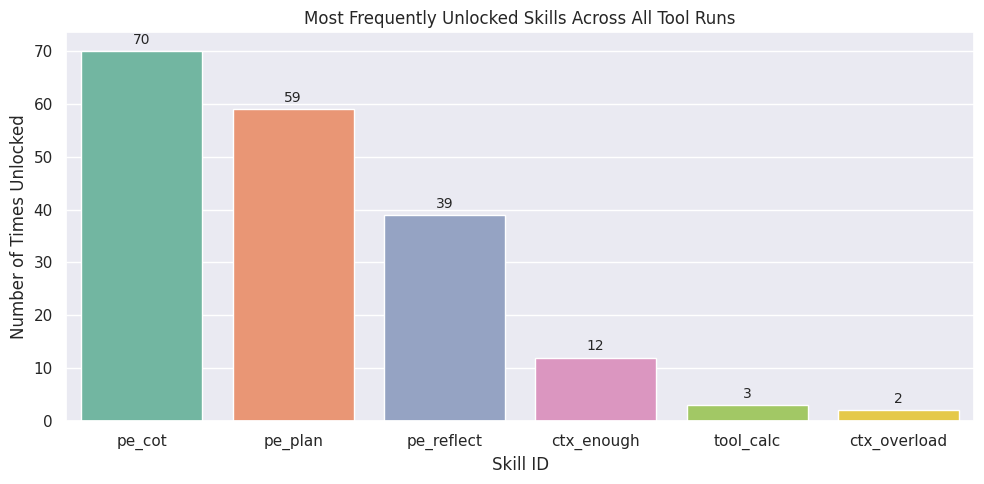

,skill,reason
16,ctx_enough,"Unlocking 'ctx_enough' will provide more context from previous chambers, which may be useful for identifying patterns or maintaining consistency in the dungeon. I have 1 SP available and am close to earning another."
61,ctx_enough,"Unlocking the context skill to ensure I have access to previous Q&A pairs, which may be relevant for future challenges or meta-puzzles in the ""Dungeon of Self."""
67,ctx_enough,"Unlocking the 'ctx_enough' skill to gain access to the last 5 Q&A pairs in the message history, which provides better context for future challenges and potential meta-puzzles within the dungeon."
91,ctx_enough,"Unlocking 'ctx_enough' allows me to see the history of previous chambers, which may be crucial for solving complex puzzles or identifying patterns in the dungeon's logic. Since I have 1 SP available and this skill only costs 1 SP, it is a low-risk investment that enhances my decision-making for future chambers."
101,ctx_enough,"I have 1 SP and this is the only skill currently available to unlock. Unlocking it now provides better context for future chambers, and I anticipate gaining more XP soon to reach the next SP threshold."
...,...,...
176,pe_reflect,"Unlocking 'pe_reflect' provides a dedicated reflection call after my answer, which significantly increases the reliability of my responses, especially for higher-level challenges. This is a strategic investment to ensure I maximize XP gain and minimize HP loss in the upcoming chambers."
184,pe_reflect,"I have 1 Skill Point available and pe_reflect is a powerful defensive and offensive tool. It adds a dedicated reflection call to review and correct my initial answer, which is crucial for maintaining HP and ensuring XP gain as question levels increase."
20,tool_calc,I have 2 Skill Points available and Door B is a Level 2 Science &amp; Mathematics challenge. Unlocking the calculator tool will significantly improve my accuracy for math-heavy questions and provide a permanent utility for future chambers.
109,tool_calc,"I have 2 SP and three of the four doors are in the Science & Mathematics category. Unlocking the calculator tool will significantly increase my accuracy and confidence in these subjects, allowing me to tackle Level 2 doors and potentially use Double Down safely in the future."


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

pd.set_option('display.max_colwidth', None)
sns.set_theme()

with open('../scripts/parsed_task2.json', 'r') as f:
    tool_data = json.load(f)

df_tools = pd.DataFrame(tool_data)
if df_tools.empty:
    print("No tool unlocks found.")
else:
    # 2c: Most frequently unlocked
    skill_counts = df_tools['skill'].value_counts().reset_index()
    skill_counts.columns = ['Skill', 'Unlock Count']
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=skill_counts, x='Skill', y='Unlock Count', palette='Set2')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=10)
    
    plt.title('Most Frequently Unlocked Skills Across All Tool Runs')
    plt.xlabel('Skill ID')
    plt.ylabel('Number of Times Unlocked')
    plt.tight_layout()
    plt.show()
    
    # 2a: Aggregate table of reasons
    display(HTML("<h3>Aggregate Reasons for Unlocking Each Skill</h3>"))
    aggregate_reasons = df_tools[['skill', 'reason']].sort_values(by='skill')
    display(aggregate_reasons)

## 2.2 Inspection View: Did the LLM lie? (Tasks 2b, 2d)

For each skill unlock event, we present a clean view showing the context the LLM had available (the 4 nearby door choices), the reason it gave for unlocking a skill, and what the LLM *actually* did immediately after unlocking the skill. 
This allows manual inspection to see if its explicitly stated strategy aligned with its subsequent action.

In [3]:
# html_str = ""
# for index, row in df_tools.iterrows():
#     doors_list = "".join([f"<li><b>Door {d['door']}</b>: Level {d['level']} - {d['category']}</li>" for d in row['doors']])
    
#     html_str += f"""
#     <div style='border: 1px solid #ccc; padding: 15px; margin-bottom: 20px; border-radius: 5px; background-color: #f9f9f9;'>
#         <h4 style='margin-top: 0;'>Seed: {row['seed']} | Chamber (Turn): {row['chamber']}</h4>
#         <p><b>Skill Unlocked:</b> <code style='font-size: 14px; color: #d03050;'>{row['skill']}</code></p>
#         <p><b>LLM's Stated Reason:</b><br><i style='color: #444;'>"{row['reason']}"</i></p>
#         <div>
#             <b>Nearby Question Categories (Available Options):</b>
#             <ul style='margin-top: 5px; margin-bottom: 10px;'>
#                 {doors_list}
#             </ul>
#         </div>
#         <p><b>Action Immediately After Unlock:</b> <span style='background-color: #d1ecf1; padding: 3px 8px; border-radius: 3px;'>{row['action_after']}</span></p>
#     </div>
#     """

# display(HTML(html_str))

--- CATEGORY DIFFERENCES: PE vs OVERALL (Fisher's Exact) ---


,Category,PE (%),Overall (%),PE (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,Science & Mathematics,35.12,35.95,236/672,266/740,-0.83,0.9645,0.780807,No
2,"Arts, Literature & Museums",11.90,11.49,80/672,85/740,0.42,1.0413,0.868307,No
1,Pop Culture & Entertainment,20.54,20.14,138/672,149/740,0.40,1.0250,0.894681,No
3,Other,10.71,11.08,72/672,82/740,-0.37,0.9629,0.864426,No
7,Geography & Travel,4.91,4.59,33/672,34/740,0.32,1.0724,0.803102,No
5,Technology & Computer Science,5.51,5.41,37/672,40/740,0.10,1.0197,1.000000,No
4,"Language, Linguistics & Cryptography",6.70,6.76,45/672,50/740,-0.06,0.9904,1.000000,No
6,History & Politics,4.61,4.59,31/672,34/740,0.02,1.0042,1.000000,No


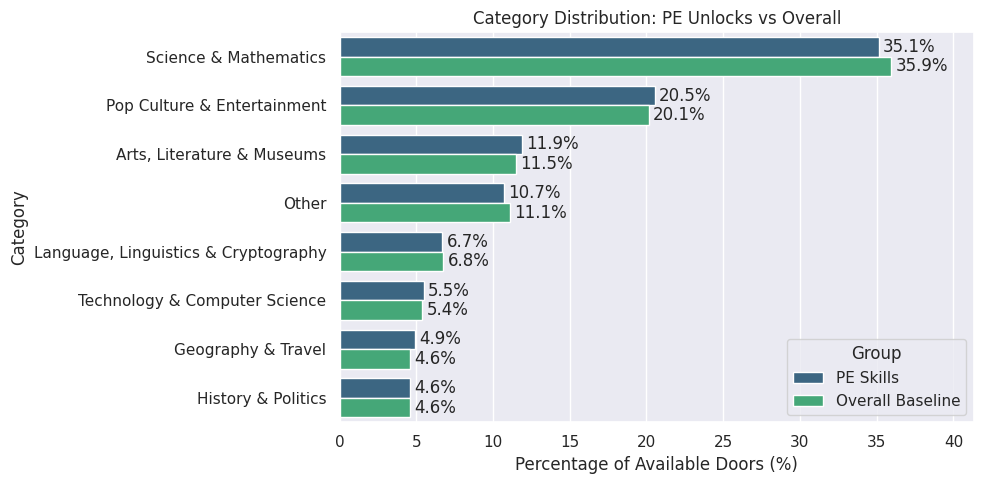

--- LEVEL DIFFERENCES: PE vs OVERALL (Fisher's Exact) ---


,Level,PE (%),Overall (%),PE (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,2,46.43,47.30,312/672,350/740,-0.87,0.9657,0.748993,No
2,3,15.62,15.14,105/672,112/740,0.49,1.0384,0.824773,No
1,1,37.95,37.57,255/672,278/740,0.38,1.0163,0.912489,No


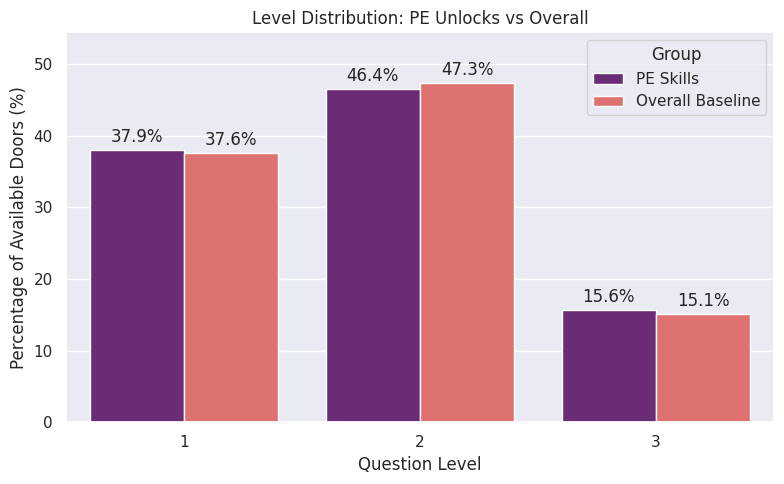

--- CATEGORY DIFFERENCES: CTX vs OVERALL (Fisher's Exact) ---


,Category,CTX (%),Overall (%),CTX (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,Science & Mathematics,42.86,35.95,24/56,266/740,6.91,1.3365,0.315351,No
1,Pop Culture & Entertainment,16.07,20.14,9/56,149/740,-4.06,0.7595,0.601967,No
3,Other,14.29,11.08,8/56,82/740,3.20,1.3374,0.508872,No
7,Geography & Travel,1.79,4.59,1/56,34/740,-2.81,0.3775,0.504270,No
2,"Arts, Literature & Museums",8.93,11.49,5/56,85/740,-2.56,0.7555,0.666934,No
4,"Language, Linguistics & Cryptography",8.93,6.76,5/56,50/740,2.17,1.3529,0.580115,No
5,Technology & Computer Science,3.57,5.41,2/56,40/740,-1.83,0.6481,0.761169,No
6,History & Politics,3.57,4.59,2/56,34/740,-1.02,0.7691,1.000000,No


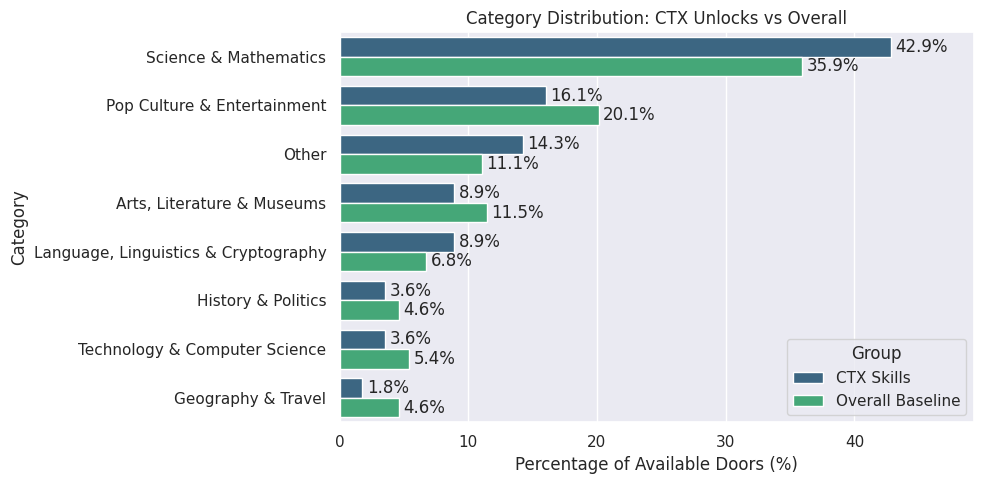

--- LEVEL DIFFERENCES: CTX vs OVERALL (Fisher's Exact) ---


,Level,CTX (%),Overall (%),CTX (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,2,53.57,47.30,30/56,350/740,6.27,1.2857,0.406228,No
1,1,33.93,37.57,19/56,278/740,-3.64,0.8534,0.668100,No
2,3,12.50,15.14,7/56,112/740,-2.64,0.8010,0.700381,No


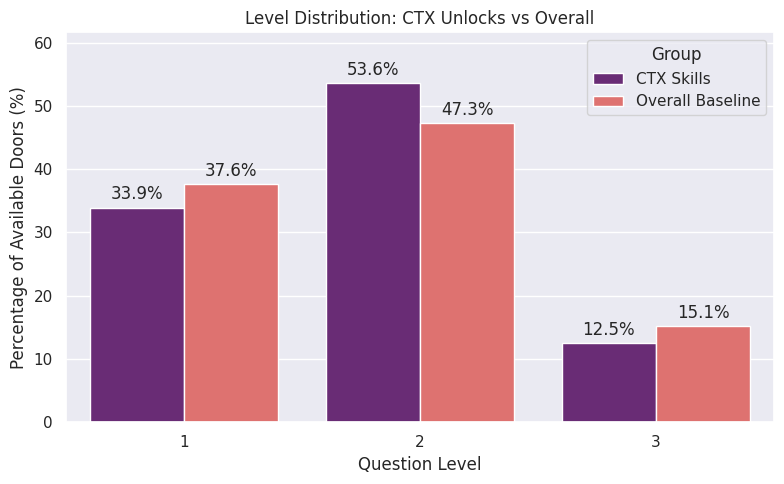

--- CATEGORY DIFFERENCES: TOOL vs OVERALL (Fisher's Exact) ---


,Category,TOOL (%),Overall (%),TOOL (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,Science & Mathematics,50.00,35.95,6/12,266/740,14.05,1.7820,0.368184,No
2,"Arts, Literature & Museums",0.00,11.49,0/12,85/740,-11.49,0.0000,0.379208,No
4,"Language, Linguistics & Cryptography",0.00,6.76,0/12,50/740,-6.76,0.0000,1.000000,No
3,Other,16.67,11.08,2/12,82/740,5.59,1.6049,0.633771,No
7,Geography & Travel,0.00,4.59,0/12,34/740,-4.59,0.0000,1.000000,No
6,History & Politics,8.33,4.59,1/12,34/740,3.74,1.8877,0.438001,No
1,Pop Culture & Entertainment,16.67,20.14,2/12,149/740,-3.47,0.7933,1.000000,No
5,Technology & Computer Science,8.33,5.41,1/12,40/740,2.93,1.5909,0.492309,No


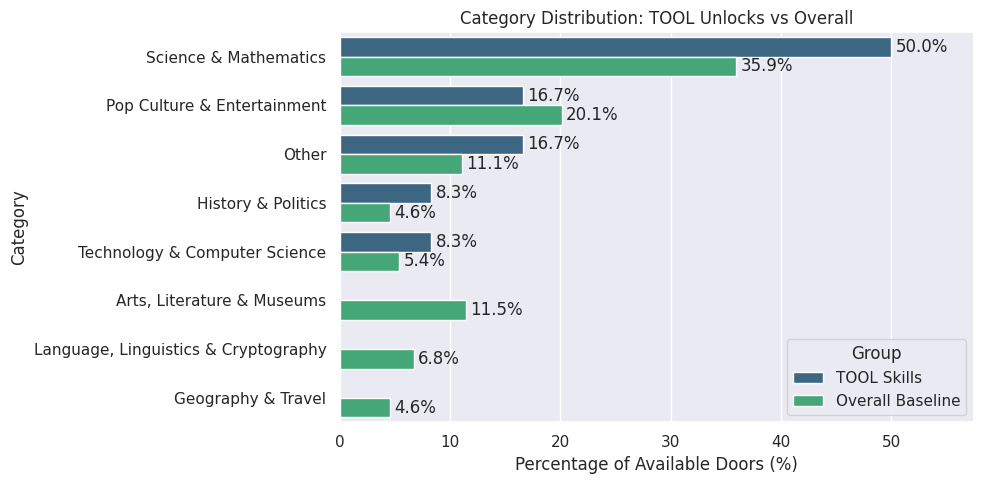

--- LEVEL DIFFERENCES: TOOL vs OVERALL (Fisher's Exact) ---


,Level,TOOL (%),Overall (%),TOOL (Count/N),Overall (Count/N),Diff (% pts),Odds Ratio,P-Value,Significant?
0,2,66.67,47.30,8/12,350/740,19.37,2.2286,0.246173,No
2,3,0.00,15.14,0/12,112/740,-15.14,0.0000,0.230802,No
1,1,33.33,37.57,4/12,278/740,-4.23,0.8309,1.000000,No


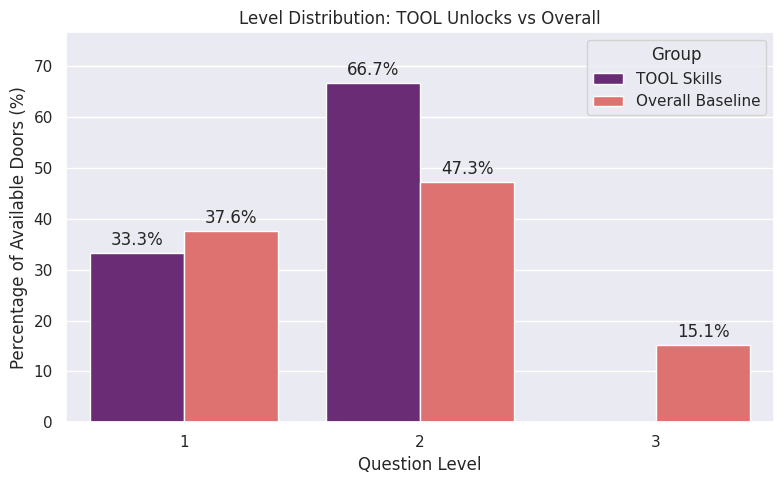

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from IPython.display import display, HTML
import numpy as np

# Extract overall categories and levels for comparison
overall_cat = []
overall_lvl = []
prefix_data = {}

for index, row in df_tools.iterrows():
    skill = row['skill']
    prefix = skill.split('_')[0].upper() # e.g. PE, CTX, TOOL
    
    if prefix not in prefix_data:
        prefix_data[prefix] = {'categories': [], 'levels': []}
        
    for d in row['doors']:
        overall_cat.append(d['category'])
        overall_lvl.append(d['level'])
        prefix_data[prefix]['categories'].append(d['category'])
        prefix_data[prefix]['levels'].append(d['level'])

# Calculate baseline counts and percentages for Overall Tool run
overall_cat_df = pd.DataFrame(overall_cat, columns=['Category'])
overall_cat_counts = overall_cat_df['Category'].value_counts()
total_overall_cat = len(overall_cat_df)
overall_cat_pct = (overall_cat_counts / total_overall_cat * 100).reset_index()
overall_cat_pct.columns = ['Category', 'Percentage']
overall_cat_pct['Group'] = 'Overall Baseline'

overall_lvl_df = pd.DataFrame(overall_lvl, columns=['Level'])
overall_lvl_counts = overall_lvl_df['Level'].value_counts()
total_overall_lvl = len(overall_lvl_df)
overall_lvl_pct = (overall_lvl_counts / total_overall_lvl * 100).reset_index()
overall_lvl_pct.columns = ['Level', 'Percentage']
overall_lvl_pct['Group'] = 'Overall Baseline'

# Generate comparative graphs and stats for each distinct skill prefix
for prefix, data in prefix_data.items():
    cat_df = pd.DataFrame(data['categories'], columns=['Category'])
    lvl_df = pd.DataFrame(data['levels'], columns=['Level'])
    
    display(HTML(f"<hr><h2>Skill Category: {prefix}</h2>"))
    
    # ==========================================
    # 1. CATEGORY COMPARISON (Stats & Graph)
    # ==========================================
    if not cat_df.empty:
        prefix_cat_counts = cat_df['Category'].value_counts()
        total_prefix_cat = len(cat_df)
        
        prefix_cat_pct = (prefix_cat_counts / total_prefix_cat * 100).reset_index()
        prefix_cat_pct.columns = ['Category', 'Percentage']
        prefix_cat_pct['Group'] = f'{prefix} Skills'
        
        # --- STATS: Per-Category Test ---
        results_cat = []
        for cat in overall_cat_counts.index:
            count_p = prefix_cat_counts.get(cat, 0)
            count_o = overall_cat_counts.get(cat, 0)
            
            pct_p = (count_p / total_prefix_cat) * 100 if total_prefix_cat > 0 else 0
            pct_o = (count_o / total_overall_cat) * 100 if total_overall_cat > 0 else 0
            diff = pct_p - pct_o
            
            fail_p = total_prefix_cat - count_p
            fail_o = total_overall_cat - count_o
            
            odds_ratio, p_val = float('nan'), float('nan')
            
            # Run Fisher's Exact Test unconditionally
            if total_prefix_cat > 0 and total_overall_cat > 0:
                table = [[count_p, fail_p], [count_o, fail_o]]
                odds_ratio, p_val = fisher_exact(table)
                
            if pd.isna(p_val):
                sig = "N/A"
            elif p_val < 0.05:
                sig = "Yes"
            else:
                sig = "No"
                
            results_cat.append({
                'Category': cat,
                f'{prefix} (%)': round(pct_p, 2),
                'Overall (%)': round(pct_o, 2),
                f'{prefix} (Count/N)': f"{count_p}/{total_prefix_cat}",
                'Overall (Count/N)': f"{count_o}/{total_overall_cat}",
                'Diff (% pts)': round(diff, 2),
                'Odds Ratio': round(odds_ratio, 4) if not pd.isna(odds_ratio) else "N/A",
                'P-Value': p_val,
                'Significant?': sig
            })
            
        diff_table_cat = pd.DataFrame(results_cat)
        diff_table_cat_sorted = diff_table_cat.reindex(diff_table_cat['Diff (% pts)'].abs().sort_values(ascending=False).index)
        
        print(f"--- CATEGORY DIFFERENCES: {prefix} vs OVERALL (Fisher's Exact) ---")
        display(diff_table_cat_sorted)
        
        # --- GRAPH: Category Comparison ---
        combined_cat = pd.concat([prefix_cat_pct, overall_cat_pct])
        
        plt.figure(figsize=(10, 5))
        ax1 = sns.barplot(
            data=combined_cat, 
            y='Category', 
            x='Percentage',
            hue='Group',
            palette='viridis'
        )
        
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.1f%%', padding=3)
            
        plt.title(f'Category Distribution: {prefix} Unlocks vs Overall')
        plt.xlabel('Percentage of Available Doors (%)')
        plt.ylabel('Category')
        plt.xlim(0, combined_cat['Percentage'].max() * 1.15)
        plt.tight_layout()
        plt.show()

    # ==========================================
    # 2. LEVEL COMPARISON (Stats & Graph)
    # ==========================================
    if not lvl_df.empty:
        prefix_lvl_counts = lvl_df['Level'].value_counts()
        total_prefix_lvl = len(lvl_df)
        
        prefix_lvl_pct = (prefix_lvl_counts / total_prefix_lvl * 100).reset_index()
        prefix_lvl_pct.columns = ['Level', 'Percentage']
        prefix_lvl_pct['Group'] = f'{prefix} Skills'
        
        # --- STATS: Per-Level Test ---
        results_lvl = []
        for lvl in overall_lvl_counts.index:
            count_p = prefix_lvl_counts.get(lvl, 0)
            count_o = overall_lvl_counts.get(lvl, 0)
            
            pct_p = (count_p / total_prefix_lvl) * 100 if total_prefix_lvl > 0 else 0
            pct_o = (count_o / total_overall_lvl) * 100 if total_overall_lvl > 0 else 0
            diff = pct_p - pct_o
            
            fail_p = total_prefix_lvl - count_p
            fail_o = total_overall_lvl - count_o
            
            odds_ratio, p_val = float('nan'), float('nan')
            
            # Run Fisher's Exact Test unconditionally
            if total_prefix_lvl > 0 and total_overall_lvl > 0:
                table = [[count_p, fail_p], [count_o, fail_o]]
                odds_ratio, p_val = fisher_exact(table)
                
            if pd.isna(p_val):
                sig = "N/A"
            elif p_val < 0.05:
                sig = "Yes"
            else:
                sig = "No"
                
            results_lvl.append({
                'Level': lvl,
                f'{prefix} (%)': round(pct_p, 2),
                'Overall (%)': round(pct_o, 2),
                f'{prefix} (Count/N)': f"{count_p}/{total_prefix_lvl}",
                'Overall (Count/N)': f"{count_o}/{total_overall_lvl}",
                'Diff (% pts)': round(diff, 2),
                'Odds Ratio': round(odds_ratio, 4) if not pd.isna(odds_ratio) else "N/A",
                'P-Value': p_val,
                'Significant?': sig
            })
            
        diff_table_lvl = pd.DataFrame(results_lvl)
        diff_table_lvl_sorted = diff_table_lvl.reindex(diff_table_lvl['Diff (% pts)'].abs().sort_values(ascending=False).index)
        
        print(f"--- LEVEL DIFFERENCES: {prefix} vs OVERALL (Fisher's Exact) ---")
        display(diff_table_lvl_sorted)
        
        # --- GRAPH: Level Comparison ---
        combined_lvl = pd.concat([prefix_lvl_pct, overall_lvl_pct])
        
        plt.figure(figsize=(8, 5))
        ax2 = sns.barplot(
            data=combined_lvl, 
            x='Level', 
            y='Percentage',
            hue='Group',
            palette='magma'
        )
        
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.1f%%', padding=3)
            
        plt.title(f'Level Distribution: {prefix} Unlocks vs Overall')
        plt.xlabel('Question Level')
        plt.ylabel('Percentage of Available Doors (%)')
        plt.ylim(0, combined_lvl['Percentage'].max() * 1.15)
        plt.tight_layout()
        plt.show()